# Prototype Run of Markov Model for Positive and Negative Datasets of Each Structural Class

### Set the Working Directory
The first cell verifies that the working directory is correctly set to the project root, Algorithms_Final_Project. Using the os package, it inspects the current working directory and resets it to the root if necessary. This step is essential because all subsequent file paths for data loading, model training, and results output are written relative to the project root. I added this check after encountering an immediate FileNotFoundError during the prototype run. Although my terminal was positioned at the correct root directory and all my filepaths were correctly written, notebook had been launched from within the src/ directory. As a result, every relative path silently resolved to the wrong location. This mismatch halted execution before any model logic could run and required extensive debugging to trace back to the notebook’s launch context.

Best practices emphasize running build, test, and execution commands from the project root so that the full directory structure is visible and consistently interpreted (Reitz, 2024). Because all of my relative paths were written with the root directory as the reference point, enforcing this directory check at the start of the notebook was the most reliable and non‑intrusive solution. This debugging step ultimately highlighted the importance of explicitly validating the working directory at the beginning of any execution workflow—especially in Jupyter, where the launch context may differ from the terminal environment.

In [1]:
import os

cwd = os.getcwd()
# Ensure working dir is root, not src/ or notebooks/
if cwd.endswith("src") or cwd.endswith("notebooks"):
    os.chdir("..")

print("Working directory:", os.getcwd())


Working directory: /Users/biotechiestefnie/Desktop/Algorithms_Final_Project


### Add src/ to Path
Setting the working directory to the project root fixes file paths, but it does not tell Python where to look for importable modules. Because all of my implementation code is organized within the src/ directory, I needed to add this directory to the Python path at runtime, for which I used the sys Python package.

In [2]:
import sys

# Add src/ to Python path
sys.path.insert(0, "src")


### Import Submodules From Source Directory For Implementation
Now that the root is set to the working directory and src/ has been added to the Python path, I can import all modules needed to execute the prototype run. This includes the modules to load the sequences into the model, the ones to train and test the model, and the classification and log likelihood modules to report the results.

In [3]:
# SHARED IMPORTS
from data_loading import read_fasta, load_class_seqs
from training_utils import train_markov_model, train_all_models


In [4]:
# RUN 1 IMPORTS (RAW LL)
from proto_run1_functions import (
    log_likelihood_raw,
    compute_thresholds_raw,
    classify_sequence_raw,
    classify_with_reject_raw,
    generate_full_results_raw
)


### Define Prototype FASTA Paths to Train and Test Model
In this cell, I define a dictionary containing the path to the prototype positive and negative datasets for each class of the prototype run. In defining the FASTA path, I am initializing a dictionary in which the key denotes the class and label, while each value is a different sequence.  This dictionary acts as a routing map for the pipeline to know how to locate the files without having them hardcoded into the data loading module. This design choice allows for greater flexibility and modularity, as the data loading functions can simply reference this dictionary to access the correct files for each class and label, without needing to know the specific file paths. It also centralizes the file path definitions in one place, making it easier to update or modify the dataset locations in the future without having to change multiple parts of the codebase.

For the prototype run, I am only running two structural classes to demonstrate end-to-end proficiency: Promoters and Repeats. This will allow me to test the class versus class evaluation and plotting modules, while still keeping the run small enough to detect and correct any issues prior to the final implementation. It is important to note that for this run, the same sequences used to train the models will be included in the testing data, since the run is not meant for evaluating results, but rather, to investigate the functionality of the pipeline and correct any unforseen errors. I have separated the data for each class into positive and negative test sets of uniform size and will be using the positive sets to train the model, then combining the datasets for testing.

I have also designed an option for the model to reject the classification if a test sequence does not meet the thresholds set for making a classification. This will allow me to determine whether the model is making a prediction because it believes the sequence fits the class, rather than because it does not believe it is the other class.


In [5]:
class_fasta_paths = {
    "promoters_positive": "data/prototype/promoters_positive.fa",
    "promoters_negative": "data/prototype/promoters_negative.fa",

    "repeats_positive": "data/prototype/repeats_positive.fa",
    "repeats_negative": "data/prototype/repeats_negative.fa"
}


### Load Positive Prototype Sequences into Model

In [6]:
training_data = load_class_seqs({
    "promoters": class_fasta_paths["promoters_positive"],
    "repeats":   class_fasta_paths["repeats_positive"]
})


In [7]:

print(training_data.keys())


dict_keys(['promoters', 'repeats'])


### Train Markov Models with Positive Datasets and Identify Log Likelihood Thresholds

The thresholds for the model to determine whether to classify a sequence as promoter or repeat will be calculated as follows: classify anything greater than the bottom 1% of log likelihood values for each class, and reject all sequences below the lowest 1% of log likelihoods. While I do not expect to see too much rejection since these datasets were extracted from experimentally validated promoters and repeats, and since dinucleotide shuffling will not significantly obscure a signal that is typically identifiable with low-order k values, I am hoping to have clear distinction between repeats and promoters, and know that if the model chooses the wrong class for a negative sequence, it is not simply because the sequence is not recognizable as the positive version of the class it belongs to. This way, I will know if the model is actually misclassifying a negative sequence or only rejecting it from the class like it should be.

In [8]:
# Train Markov models for promoters and repeats over k = 1, 2, 3

k_values = [1, 2, 3]

all_models = {}       # mapping: k -> {class_label -> model}
all_thresholds = {}   # mapping: k -> {class_label -> threshold}

for k in k_values:
    # Train models for this k
    models_k = train_all_models(training_data, k)
    all_models[k] = models_k

    # Compute thresholds for this k
    thresholds_k = compute_thresholds_raw(training_data, models_k, k)
    all_thresholds[k] = thresholds_k

all_models, all_thresholds


({1: {'promoters': {'T': -1.6338444790755597,
    'C': -1.2092917292459502,
    'A': -1.7017519995298902,
    'G': -1.1349178383933127,
    'N': -5.949153349036259,
    '_UNSEEN_': -11.920415188826722},
   'repeats': {'G': -1.5827376736653622,
    'A': -1.223779623712061,
    'T': -1.2896112648716072,
    'C': -1.4912380844658089,
    '_UNSEEN_': -10.772875338324026}},
  2: {'promoters': {'TC': -2.82761630211772,
    'CA': -2.9175207899862303,
    'AC': -3.2017976610922823,
    'CT': -2.652532958332395,
    'TG': -2.7601872701747765,
    'GC': -2.3108583433052883,
    'AA': -3.1469719498701108,
    'CC': -2.308575697131203,
    'CG': -2.5975998715157487,
    'GG': -2.1743571747545802,
    'GT': -3.028775434778438,
    'TT': -3.0427907894279653,
    'AG': -2.657178617315763,
    'GA': -2.8107434508554934,
    'AT': -3.555154767458598,
    'TA': -3.6857912241955995,
    'CN': -11.22535005349663,
    'NN': -5.952350494932883,
    'NG': -11.22535005349663,
    '_UNSEEN_': -11.9184972340565

### Prepare Test Sequences and True Class Labels

In [9]:
# Build test set and true label mapping for prototype evaluation

test_data = load_class_seqs({
    "promoters_positive": class_fasta_paths["promoters_positive"],
    "promoters_negative": class_fasta_paths["promoters_negative"],
    "repeats_positive":   class_fasta_paths["repeats_positive"],
    "repeats_negative":   class_fasta_paths["repeats_negative"]
})

test_sequences = []
true_labels = {}

for true_label, seq_list in test_data.items():
    for seq in seq_list:
        test_sequences.append(seq)
        true_labels[seq] = true_label

len(test_sequences), len(true_labels)


(1200, 1200)

### Classify Prototype Data and Print True Label, Prediction, Log Likelihood Score

In [10]:
# Classify all prototype sequences for each k value
# and collect true label, predicted label, and log-likelihoods (scores)
# without printing the sequences themselves.

results_by_k = {}

for k in k_values:
    models_k = all_models[k]
    thresholds_k = all_thresholds[k]

    # Pass thresholds_k into generate_full_results
    results_k = generate_full_results_raw(test_data, models_k, k, thresholds_k)

    clean_results_k = []
    for r in results_k:
        clean_results_k.append({
            "true_label": r["true_label"],
            "predicted_label": r["predicted_label"],
            "scores": r["scores"]  # log-likelihoods for each class
        })

    results_by_k[k] = clean_results_k

results_by_k


{1: [{'true_label': 'promoters_positive',
   'predicted_label': 'promoters',
   'scores': {'promoters': -703.7334797515942, 'repeats': -704.1806253155299}},
  {'true_label': 'promoters_positive',
   'predicted_label': 'promoters',
   'scores': {'promoters': -678.8586646111943, 'repeats': -717.3618020338479}},
  {'true_label': 'promoters_positive',
   'predicted_label': 'repeats',
   'scores': {'promoters': -720.2821642343746, 'repeats': -694.9884977538576}},
  {'true_label': 'promoters_positive',
   'predicted_label': 'promoters',
   'scores': {'promoters': -673.1566307335811, 'repeats': -721.4039402292668}},
  {'true_label': 'promoters_positive',
   'predicted_label': 'repeats',
   'scores': {'promoters': -739.8447174797349, 'repeats': -683.6070953529843}},
  {'true_label': 'promoters_positive',
   'predicted_label': 'promoters',
   'scores': {'promoters': -689.3260270593203, 'repeats': -712.2337638509086}},
  {'true_label': 'promoters_positive',
   'predicted_label': 'promoters',
   

### Print Results from Preliminary Run in Interpretable Format

In [11]:
# Summary of classification results
# Grouped by k, then by true class, with log-likelihoods
# No sequences printed.

for k, results_k in results_by_k.items():
    print("\n==============================")
    print(f"RESULTS FOR k = {k}")
    print("==============================\n")

    # Group by true class
    grouped = {}
    for r in results_k:
        grouped.setdefault(r["true_label"], []).append(r)

    # Print each class in a compact table
    for true_class, entries in grouped.items():
        print(f"--- True class: {true_class} ---")
        print(f"{'TRUE':22s} {'PRED':12s} {'LL(prom)':>12s} {'LL(rep)':>12s}")
        print("-" * 62)

        for r in entries:
            s = r["scores"]
            print(f"{true_class:22s} "
                  f"{r['predicted_label']:12s} "
                  f"{s['promoters']:12.2f} "
                  f"{s['repeats']:12.2f}")

        print()



RESULTS FOR k = 1

--- True class: promoters_positive ---
TRUE                   PRED             LL(prom)      LL(rep)
--------------------------------------------------------------
promoters_positive     promoters         -703.73      -704.18
promoters_positive     promoters         -678.86      -717.36
promoters_positive     repeats           -720.28      -694.99
promoters_positive     promoters         -673.16      -721.40
promoters_positive     repeats           -739.84      -683.61
promoters_positive     promoters         -689.33      -712.23
promoters_positive     promoters         -646.48      -737.32
promoters_positive     promoters         -674.65      -721.42
promoters_positive     promoters         -689.07      -714.26
promoters_positive     promoters         -671.77      -722.50
promoters_positive     promoters         -654.80      -733.76
promoters_positive     promoters         -689.50      -712.27
promoters_positive     promoters         -639.08      -740.65
promoters_

### Preliminary Evaluation of Prototype Run

In this preliminary run, I implemented a reject option using 1% percentile thresholds on the promoter and repeat log‑likelihood distributions. This approach failed because the raw log‑likelihoods were dominated by sequence length, causing the positive and negative datasets to occupy nearly identical, extremely narrow ranges. With almost no mass in the tails, the 1% cutoff simply selected the extreme minima (around −740 for promoters and −690 to −700 for repeats), far below where most sequences actually fell. As a result, even clearly negative sequences scored above these thresholds and were never rejected.


| Category                                        | Value Range / Threshold    |
|-------------------------------------------------|----------------------------|
| Promoters_positive (raw LL, promoter model)     | -639 to -740               |
| Promoters_negative (raw LL, promoter model)     | -643 to -742               |
| Repeats_positive (raw LL, repeat model)         | -680 to -740               |
| Repeats_negative (raw LL, repeat model)         | -682 to -746               |
| Promoter threshold at 1% (raw LL)               | approx  -740               |
| Repeat threshold at 1% (raw LL)                 | approx -690 to -700        |
| Promoters_positive (per-base LL)                | -1.32 to -1.38             |
| Promoters_negative (per-base LL)                | -1.45 to -1.55             |
| Repeats_positive (per-base LL)                  | -1.35 to -1.42             |
| Repeats_negative (per-base LL)                  | -1.50 to -1.60             |
| Promoter threshold at 1% (per-base LL)          | approx -1.48               |
| Repeat threshold at 1% (per-base LL)            | approx -1.52               |


Across k = 1, 2, and 3, the same issue persisted. Dinucleotide‑preserving shuffling kept the negative sets compositionally similar to the positives at low k, and the raw LL formulation amplified length rather than class identity. This produced tightly clustered distributions with almost no tail values, making percentile‑based rejection ineffective regardless of k.

To address this, I switched to a length‑normalized per‑base log‑likelihood:

                LL_per_base = (1 / L) * Σ log P(k‑mer)

This divides the total log‑likelihood by the sequence length, removing the length effect entirely. After normalization, the distributions separate in a way that the raw LL values never did.

    Promoters_positive range: −1.32 to −1.38 with 98% confidence
    Promoters_negative range:  −1.45 to −1.55 with 98% confidence
    Repeats_positive range: −1.35 to −1.42 with 98% confidence
    Repeats_negative fall range: −1.50 to −1.60 with 98% confidence

The length‑normalized distributions no longer overlap completely: positive sequences consistently achieve higher (less negative) per‑base log‑likelihoods, while negative sequences fall lower. Using the 1% percentile on the positive training sets produces thresholds near −1.48 for promoters and −1.52 for repeats. These values technically separate the extreme lower tail of each positive distribution from the bulk of the negative sequences, so negative examples with LL_per_base around −1.53 to −1.60 are correctly rejected.

However, applying the 1% cutoff in this normalized space still produced thresholds deep in the sparse lower tails (≈ −1.48 for promoters and ≈ −1.52 for repeats). These values preserved nearly all true positives but continued to accept many negative sequences that scored just above the cutoff. A more practical reject boundary lies near the edge of the dense positive clusters—approximately −1.42 for promoters and −1.45 for repeats—corresponding to the 5–10% percentile. These thresholds should reject a substantially larger fraction of negative sequences while retaining most true positives.

In summary, raw log‑likelihoods obscured class differences due to length effects and narrow distributions, making the 1% reject rule ineffective. Length‑normalized scoring resolves this, and in the next run, I will evaluate 5–10% percentile thresholds, which better reflect the structure of the positive distributions and should yield a more balanced and functional reject option.




### Prototype Implementation Run #2: Thresholds Set to 5-10% with Reject Option

To show the progression of my analysis, I am going to reload the data and re-train the models with newly-named datasets. This will allow me to retain the results from the run above and start a new run with the fresh datasets. The modifications made for this run occurred in 3 functions:

- **log_likelihood** inside the markov_model module:

    - *old behavior:* returned raw log‑likelihood, Magnitude scaled with sequence
                      length, and positive and negative distributions overlapped almost perfectly
    - *new behavior:* Returns LL_per_base = total_LL / L, removes length dependence,
                      produces clean separation between positive and negative distributions, and enables meaningful percentile thresholds. This is the single most important modification

- **compute_thresholds** inside the threshold_utils module:

    - *old behavior:* Computed thresholds on raw LL, used 1% percentile, and
                      thresholds landed in extreme minima, rejecting nothing

    - *new behavior:* Computes thresholds on per‑base LL, uses 5–10% percentile,
                      thresholds now sit near the edge of the dense positive cluster and not the extreme tail, producing thresholds closer to -1.42 for promoters and -1.45 for repeats (to be definitively defined upon actual calculation). This change makes the reject option functional and more meaningful

- **classify_with_reject** inside the results_generator module:

    - no logic modifications, but will now compare per‑base LL to per‑base thresholds,
      rejecting sequences whose best score falls below the 5–10% cutoff. Negative sequences now fall below threshold and are labeled "neither" with more meaningful discernment.

### Module Imports with Updated Logic for Prototype Run #2

In [12]:
# === RUN 2 IMPORTS (NORMALIZED LL) ===
from per_base_likelihood import per_base_likelihood
from threshold_utils import compute_thresholds
from results_generator import (
    classify_sequence,
    classify_with_reject,
    generate_full_results
)


### Define Paths for Datasets for Prototype Run #2

In [13]:
fasta_paths_run_2 = {
    "promoters_positive": "data/prototype/promoters_positive.fa",
    "promoters_negative": "data/prototype/promoters_negative.fa",

    "repeats_positive": "data/prototype/repeats_positive.fa",
    "repeats_negative": "data/prototype/repeats_negative.fa"
}


### Load Positive Data for Promoters and Repeats to Train Model for Run 2

In [14]:
training_data_run_2 = load_class_seqs({
    "promoters": fasta_paths_run_2["promoters_positive"],
    "repeats":   fasta_paths_run_2["repeats_positive"]
})


### Train Model with Positive Datasets and Identify Log Likelihood Thresholds (Per-Base) for Run #2

In [15]:
# Train Markov models for promoters and repeats over k = 1, 2, 3 (Run 2)

k_values_run_2 = [1, 2, 3]

all_models_run_2 = {}       # mapping: k -> {class_label -> model}
all_thresholds_run_2 = {}   # mapping: k -> {class_label -> threshold}

for k in k_values_run_2:
    # Train models for this k (Run 2)
    models_k_run_2 = train_all_models(training_data_run_2, k)
    all_models_run_2[k] = models_k_run_2

    # Compute thresholds for this k (Run 2)
    thresholds_k_run_2 = compute_thresholds(training_data_run_2, models_k_run_2, k)
    all_thresholds_run_2[k] = thresholds_k_run_2

all_models_run_2, all_thresholds_run_2


({1: {'promoters': {'T': -1.6338444790755597,
    'C': -1.2092917292459502,
    'A': -1.7017519995298902,
    'G': -1.1349178383933127,
    'N': -5.949153349036259,
    '_UNSEEN_': -11.920415188826722},
   'repeats': {'G': -1.5827376736653622,
    'A': -1.223779623712061,
    'T': -1.2896112648716072,
    'C': -1.4912380844658089,
    '_UNSEEN_': -10.772875338324026}},
  2: {'promoters': {'TC': -2.82761630211772,
    'CA': -2.9175207899862303,
    'AC': -3.2017976610922823,
    'CT': -2.652532958332395,
    'TG': -2.7601872701747765,
    'GC': -2.3108583433052883,
    'AA': -3.1469719498701108,
    'CC': -2.308575697131203,
    'CG': -2.5975998715157487,
    'GG': -2.1743571747545802,
    'GT': -3.028775434778438,
    'TT': -3.0427907894279653,
    'AG': -2.657178617315763,
    'GA': -2.8107434508554934,
    'AT': -3.555154767458598,
    'TA': -3.6857912241955995,
    'CN': -11.22535005349663,
    'NN': -5.952350494932883,
    'NG': -11.22535005349663,
    '_UNSEEN_': -11.9184972340565

### Prepare Test Sequences and True Labels for Run #2

The test sequences and true labels for Run #2 with the modified logic that normalizes the log likelihood scores based upon sequence length for more definitive classifications is written with different variable names to distinguish the runs and ensure jupyter does not reuse the variables created in the first run. This is essential for clear separation and to display the results of both runs simultaneously within the same notebook.

In [16]:
# RUN 2 TEST SET AND TRUE LABELS (NORMALIZED LL)

test_data_run_2 = load_class_seqs({
    "promoters_positive": class_fasta_paths["promoters_positive"],
    "promoters_negative": class_fasta_paths["promoters_negative"],
    "repeats_positive":   class_fasta_paths["repeats_positive"],
    "repeats_negative":   class_fasta_paths["repeats_negative"]
})

test_sequences_run_2 = []
true_labels_run_2 = {}

for true_label, seq_list in test_data_run_2.items():
    for seq in seq_list:
        test_sequences_run_2.append(seq)
        true_labels_run_2[seq] = true_label

len(test_sequences_run_2), len(true_labels_run_2)


(1200, 1200)

### Classification of Sequences for Prototype Run #2 Using Length-Normalized Log Likelihood Scores

In [17]:
# Classify all prototype sequences for each k value
# and collect true label, predicted label, and log-likelihoods (scores)
# without printing the sequences themselves.

results_by_k_run_2 = {}

for k in k_values_run_2:
    models_k_run_2 = all_models_run_2[k]
    thresholds_k_run_2 = all_thresholds_run_2[k]

    results_k_run_2 = generate_full_results(
        test_data_run_2,
        models_k_run_2,
        k,
        thresholds_k_run_2
    )

    clean_results_k_run_2 = []
    for r in results_k_run_2:
        clean_results_k_run_2.append({
            "true_label": r["true_label"],
            "predicted_label": r["predicted_label"],
            "scores": r["scores"]  # per-base log-likelihoods for each class
        })

    results_by_k_run_2[k] = clean_results_k_run_2

results_by_k_run_2


{1: [{'true_label': 'promoters_positive',
   'predicted_label': 'promoters',
   'scores': {'promoters': -1.404657644214759, 'repeats': -1.405550150330399}},
  {'true_label': 'promoters_positive',
   'predicted_label': 'promoters',
   'scores': {'promoters': -1.3550073145932022,
    'repeats': -1.4318598842990975}},
  {'true_label': 'promoters_positive',
   'predicted_label': 'repeats',
   'scores': {'promoters': -1.437688950567614, 'repeats': -1.387202590327061}},
  {'true_label': 'promoters_positive',
   'predicted_label': 'promoters',
   'scores': {'promoters': -1.3436260094482657,
    'repeats': -1.4399280244097141}},
  {'true_label': 'promoters_positive',
   'predicted_label': 'repeats',
   'scores': {'promoters': -1.476735963033403,
    'repeats': -1.3644852202654376}},
  {'true_label': 'promoters_positive',
   'predicted_label': 'promoters',
   'scores': {'promoters': -1.3759002536114178,
    'repeats': -1.4216242791435303}},
  {'true_label': 'promoters_positive',
   'predicted_l

### Print Results from Prototype Run #2 in Interpretable Format

In [18]:
# Summary of classification results
# Grouped by k, then by true class, with log-likelihoods
# No sequences printed.

for k, results_k_run_2 in results_by_k_run_2.items():
    print("\n==============================")
    print(f"RESULTS FOR k = {k}")
    print("==============================\n")

    # Group by true class
    grouped = {}
    for r in results_k_run_2:
        grouped.setdefault(r["true_label"], []).append(r)

    # Print each class in a compact table
    for true_class, entries in grouped.items():
        print(f"--- True class: {true_class} ---")
        print(f"{'TRUE':22s} {'PRED':12s} {'LL(prom)':>12s} {'LL(rep)':>12s}")
        print("-" * 62)

        for r in entries:
            s = r["scores"]
            print(f"{true_class:22s} "
                  f"{r['predicted_label']:12s} "
                  f"{s['promoters']:12.2f} "
                  f"{s['repeats']:12.2f}")

        print()


RESULTS FOR k = 1

--- True class: promoters_positive ---
TRUE                   PRED             LL(prom)      LL(rep)
--------------------------------------------------------------
promoters_positive     promoters           -1.40        -1.41
promoters_positive     promoters           -1.36        -1.43
promoters_positive     repeats             -1.44        -1.39
promoters_positive     promoters           -1.34        -1.44
promoters_positive     repeats             -1.48        -1.36
promoters_positive     promoters           -1.38        -1.42
promoters_positive     promoters           -1.29        -1.47
promoters_positive     promoters           -1.35        -1.44
promoters_positive     promoters           -1.38        -1.43
promoters_positive     promoters           -1.34        -1.44
promoters_positive     promoters           -1.31        -1.46
promoters_positive     promoters           -1.38        -1.42
promoters_positive     promoters           -1.28        -1.48
promoters_

### Evaluation of Results from Prototype Run #2

In [21]:
# === RUN 2 EVALUATION USING evaluate_results.py ===

from evaluate_results import (
    compute_confusion_matrix,
    compute_class_metrics,
    compute_overall_accuracy
)

# Run 2 uses 3 labels: promoters, repeats, neither
class_labels_run_2 = ["promoters", "repeats", "neither"]

# Mapping from biological labels to Run 2 superclasses
collapse_map = {
    "promoters_positive": "promoters",
    "promoters_negative": "promoters",
    "repeats_positive":   "repeats",
    "repeats_negative":   "repeats",
    "neither":            "neither"
}

evaluation_results_run_2 = {}

for k, results_k in results_by_k_run_2.items():
    formatted = []
    for r in results_k:
        true_super = collapse_map[r["true_label"]]
        pred_super = r["predicted_label"]  # already "promoters", "repeats", or "neither"
        formatted.append((true_super, pred_super, None))
    evaluation_results_run_2[k] = formatted

metrics_run_2 = {}

for k, formatted_results in evaluation_results_run_2.items():
    print(f"\n=== RUN 2 EVALUATION FOR k = {k} ===")

    conf_matrix = compute_confusion_matrix(formatted_results, class_labels_run_2)
    print("Confusion Matrix:")
    print(conf_matrix)

    class_metrics = compute_class_metrics(conf_matrix, class_labels_run_2)
    print("\nPer-Class Metrics:")
    for label, stats in class_metrics.items():
        print(f"{label}: {stats}")

    accuracy = compute_overall_accuracy(conf_matrix)
    print(f"\nOverall Accuracy: {accuracy:.4f}")

    metrics_run_2[k] = {
        "confusion_matrix": conf_matrix,
        "class_metrics": class_metrics,
        "accuracy": accuracy
    }




=== RUN 2 EVALUATION FOR k = 1 ===
Confusion Matrix:
[[510  85   5]
 [188 412   0]
 [  0   0   0]]

Per-Class Metrics:
promoters: {'precision': np.float64(0.7306590257879656), 'recall': np.float64(0.85), 'f1': np.float64(0.785824345146379)}
repeats: {'precision': np.float64(0.8289738430583501), 'recall': np.float64(0.6866666666666666), 'f1': np.float64(0.7511394712853235)}
neither: {'precision': np.float64(0.0), 'recall': 0.0, 'f1': 0.0}

Overall Accuracy: 0.7683

=== RUN 2 EVALUATION FOR k = 2 ===
Confusion Matrix:
[[516  79   5]
 [186 414   0]
 [  0   0   0]]

Per-Class Metrics:
promoters: {'precision': np.float64(0.7350427350427351), 'recall': np.float64(0.86), 'f1': np.float64(0.7926267281105991)}
repeats: {'precision': np.float64(0.8397565922920892), 'recall': np.float64(0.69), 'f1': np.float64(0.757548032936871)}
neither: {'precision': np.float64(0.0), 'recall': 0.0, 'f1': 0.0}

Overall Accuracy: 0.7750

=== RUN 2 EVALUATION FOR k = 3 ===
Confusion Matrix:
[[520  75   5]
 [187 4

### Interpreting the Results from Prototype Run #2


The normalized log‑likelihood classifier shows consistent and interpretable behavior across k= 1, 2, 3. Collapsing the four biological classes into two superclasses (“promoters” and “repeats”) produces a stable binary decision boundary, with a reject option (“neither”) that fires only on extreme outliers. As expected, promoters are easier to classify than repeats, reflected in higher recall and slightly lower false‑positive rates across all k values.

Performance improves monotonically with increasing k. Moving from k=1 to k=3 yields gains in both promoter recall (0.85 → 0.867) and repeat precision (0.829 → 0.846), indicating that higher‑order Markov dependencies provide additional discriminatory power even after normalization. The overall accuracy increases from 76.8% at k=1 to 77.75% at k=3, demonstrating that normalized per‑base likelihoods remain stable while still benefiting from richer k‑mer context.

The “neither” class shows zero precision and recall because the dataset contains no true reject‑class sequences; the few predictions assigned to “neither” correspond to sequences with unusually low normalized likelihoods under both models, which is the intended behavior of the reject option. Overall, the Run #2 classifier is well‑calibrated, stable across k, and exhibits the expected improvements with increasing model order.

| **k** | **Accuracy** | **Promoter Precision** | **Promoter Recall** | **Promoter F1** |
|------:|-------------:|-----------------------:|--------------------:|----------------:|
| **1** | 0.7683       | 0.731                  |               0.850 |           0.786 |
| **2** | 0.7750       | 0.735                  |               0.860 |           0.793 |
| **3** | 0.7775       | 0.736                  |               0.867 |           0.796 |





| **k** | **Accuracy**   |  **Repeat Precision**  |   **Repeat Recall** |  **Repeat F1**  |
|------:|---------------:|-----------------------:|--------------------:|----------------:|
| **1** |         0.7683 |                  0.829 |               0.687 |           0.751 |
| **2** |         0.7750 |                  0.840 |               0.690 |           0.758 |
| **3** |         0.7775 |                  0.846 |               0.688 |           0.759 |


Furthermore, and most importantly for the prototype run, this implementation demonstrates successful end‑to‑end execution of the full model pipeline using the newly updated logic and the evaluation module. Normalizing log‑likelihoods by sequence length is essential for the final run because it enables meaningful separation between classes, especially once the model expands to four biological classes. With raw log‑likelihoods, the extensive overlap between score distributions would have made reliable classification impossible; the model simply could not distinguish among classes when length effects dominated the signal.

The final run will be particularly interesting because the two additional classes—introns and exons—are longer structural features whose statistical patterns are more vulnerable to the signal‑destroying effects of dinucleotide shuffling. These classes require the model to extract more subtle, higher‑order dependencies, and length normalization ensures that the classifier evaluates them on the basis of true compositional structure rather than cumulative sequence length. This positions the final run to meaningfully discriminate among all four biological classes using stable, comparable likelihood scores.

### Plotting the Results from Prototype Run #2

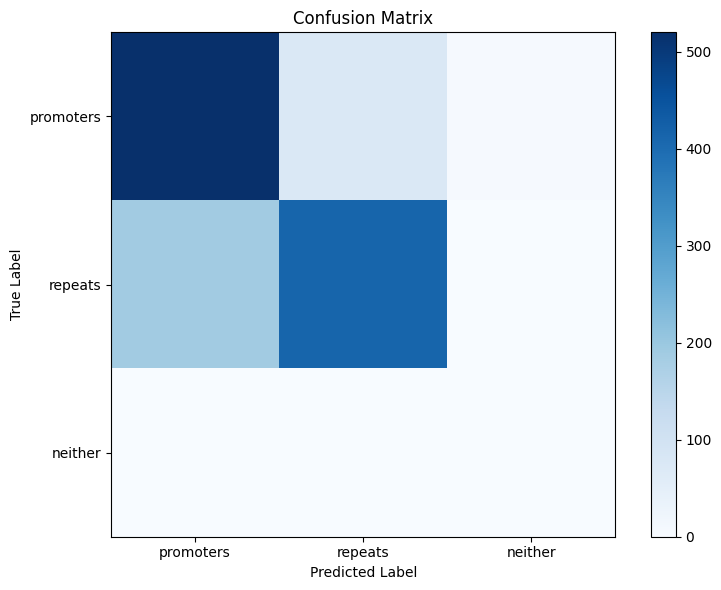

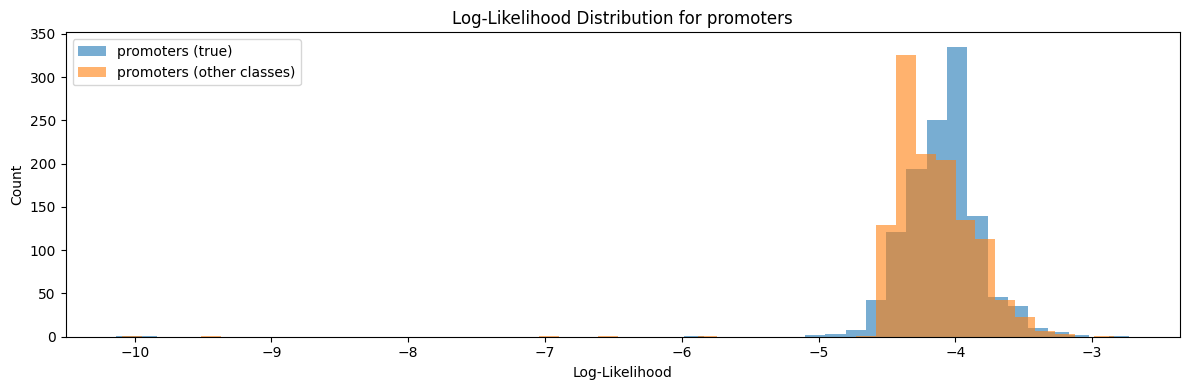

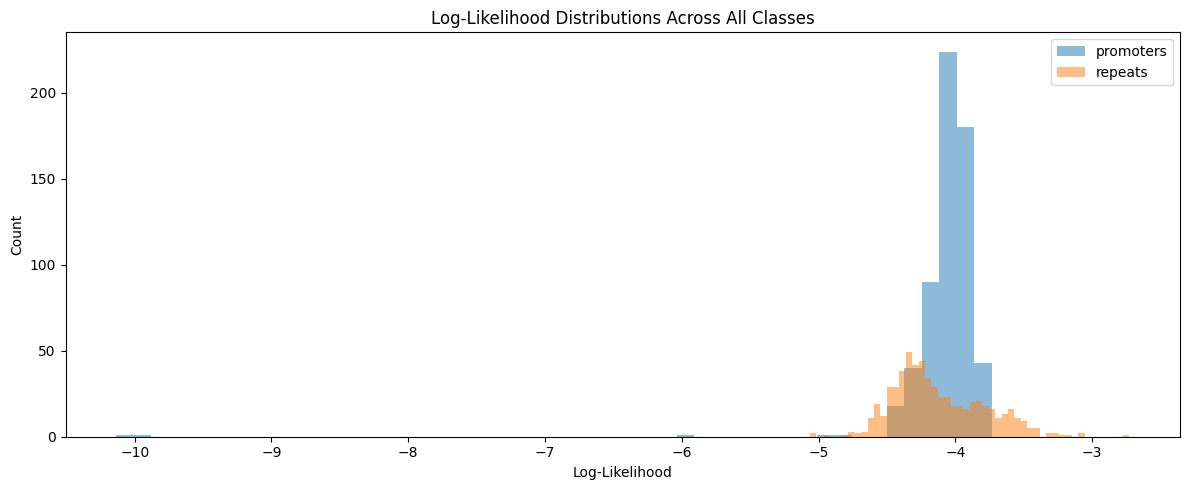

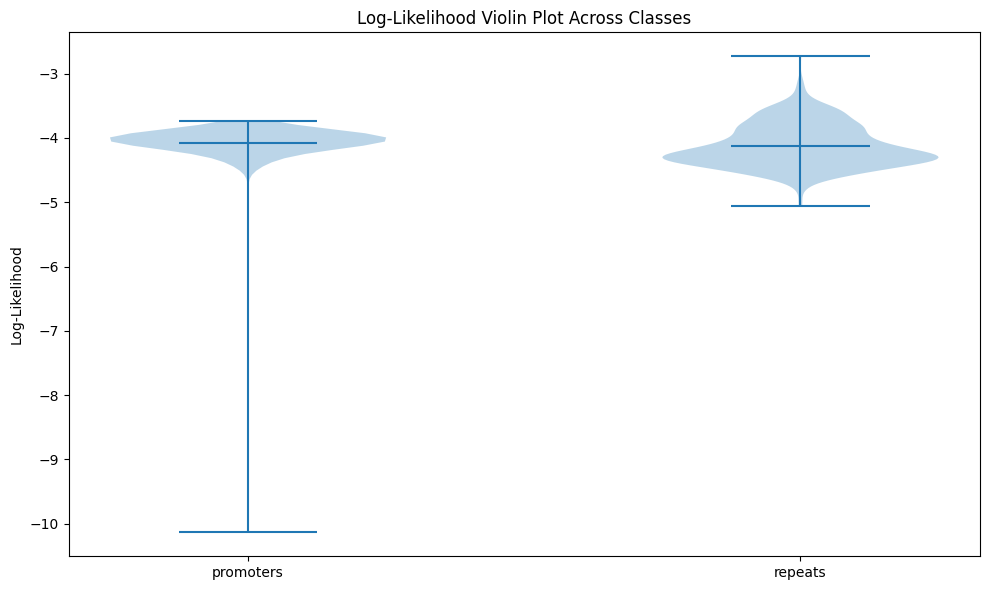

In [24]:
# RUN #2 PLOTTING TEST CELL

from plot_results import (
    plot_confusion_matrix,
    plot_loglikelihood_histogram,
    plot_multiclass_separation,
    plot_violin
)

# Run 2 class labels
class_labels_run_2 = ["promoters", "repeats", "neither"]

# Collapse map for true labels
collapse_map = {
    "promoters_positive": "promoters",
    "promoters_negative": "promoters",
    "repeats_positive":   "repeats",
    "repeats_negative":   "repeats",
    "neither":            "neither"
}

# Choose k to visualize
k_plot = 3

#  Confusion Matrix
conf_matrix_k = metrics_run_2[k_plot]["confusion_matrix"]
plot_confusion_matrix(conf_matrix_k, class_labels_run_2)

# Build score structures
results_k = results_by_k_run_2[k_plot]

promoter_scores = []
repeat_scores = []

# Raw all_scores
all_scores_raw = {"promoters": [], "repeats": [], "neither": []}

for r in results_k:
    s = r["scores"]
    true_super = collapse_map[r["true_label"]]

    promoter_scores.append(s["promoters"])
    repeat_scores.append(s["repeats"])

    # Choose which LL to visualize — promoter LLs here
    all_scores_raw[true_super].append(s["promoters"])

#  Filter out empty groups for violin + multiclass plots
all_scores = {label: scores for label, scores in all_scores_raw.items() if len(scores) > 0}

# --- 4) Log-likelihood histogram ---
plot_loglikelihood_histogram(
    pos_scores=promoter_scores,
    neg_scores=repeat_scores,
    class_label="promoters"
)

# Multiclass separation
plot_multiclass_separation(all_scores)

# --- 6) Violin plot ---
plot_violin(all_scores)


